<a href="https://colab.research.google.com/github/Al3x4ndra/Perceptron-ML/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia (Perceptron do zero): 1.0
Acurácia (sklearn Perceptron): 1.0


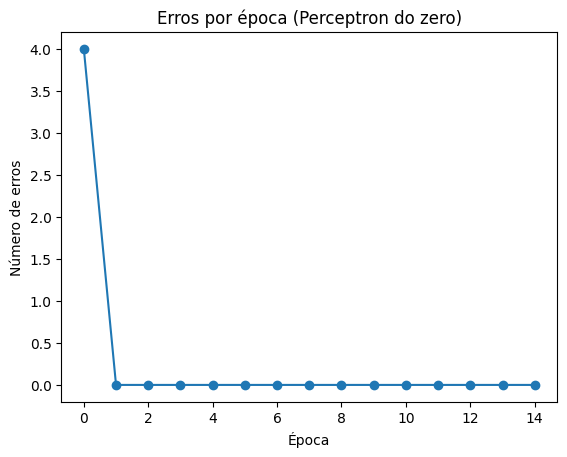

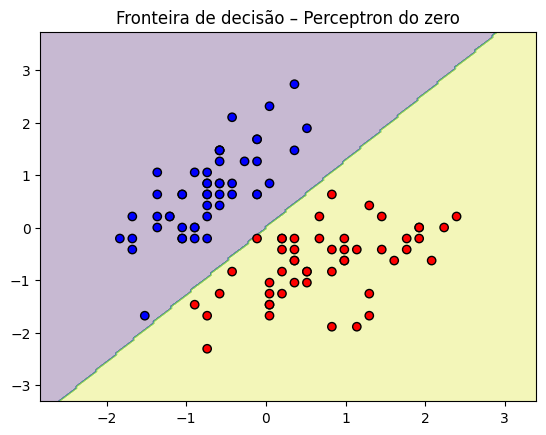

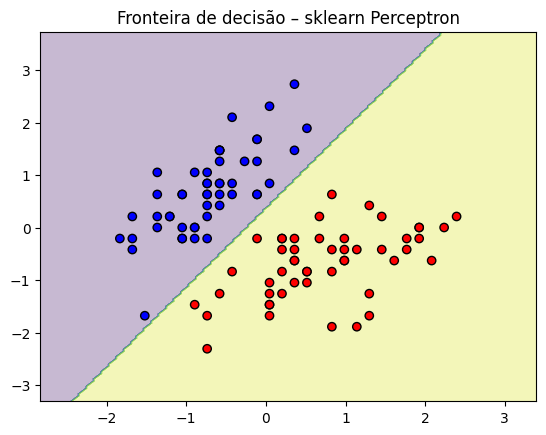

In [4]:
# ============================================
# PERCEPTRON – IMPLEMENTAÇÃO SIMPLES
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

# ----------------------------
# 1) Carregar Dataset (Iris)
# ----------------------------
iris = datasets.load_iris()
X = iris.data[:, :2]   # pegar apenas 2 features para plotar
y = iris.target

# Vamos usar apenas Setosa e Versicolor (classes 0 e 1)
mask = y != 2
X = X[mask]
y = y[mask]

# Transformar y para {-1, +1}
y = np.where(y == 0, -1, 1)

# Padronizar
sc = StandardScaler()
X = sc.fit_transform(X)

# Dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------------------------
# 2) Perceptron do zero (implementação simples)
# ---------------------------------------------
class PerceptronScratch:
    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors = []

        for _ in range(self.epochs):
            error_count = 0
            for xi, yi in zip(X, y):
                update = yi * (np.dot(self.w, xi) + self.b)
                if update <= 0:        # errou
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    error_count += 1
            self.errors.append(error_count)

    def predict(self, X):
        return np.where(np.dot(X, self.w) + self.b >= 0, 1, -1)


# Treinar perceptron simples
p = PerceptronScratch(lr=0.1, epochs=15)
p.fit(X_train, y_train)

# Avaliação
pred_scratch = p.predict(X_test)
acc_scratch = accuracy_score(y_test, pred_scratch)
print("Acurácia (Perceptron do zero):", acc_scratch)

# --------------------------
# 3) Perceptron do sklearn
# --------------------------
skp = Perceptron(max_iter=1000, tol=1e-3, eta0=0.1)
skp.fit(X_train, y_train)

pred_sklearn = skp.predict(X_test)
acc_sklearn = accuracy_score(y_test, pred_sklearn)
print("Acurácia (sklearn Perceptron):", acc_sklearn)

# -----------------------------
# 4) Gráfico de erros por época
# -----------------------------
plt.plot(p.errors, marker='o')
plt.title("Erros por época (Perceptron do zero)")
plt.xlabel("Época")
plt.ylabel("Número de erros")
plt.savefig("erros_epoca.png", dpi=300)
plt.show()

# ------------------------------------------
# 5) Fronteira de decisão (2 features)
# ------------------------------------------
def plot_decision_boundary(model, X, y, title, filename):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolor='k')
    plt.title(title)
    plt.savefig(filename, dpi=300)
    plt.show()

plot_decision_boundary(p, X, y, "Fronteira de decisão – Perceptron do zero",
                       "fronteira_scratch.png")
plot_decision_boundary(skp, X, y, "Fronteira de decisão – sklearn Perceptron",
                       "fronteira_sklearn.png")
